Master table shape: (50, 18)

Top 10 departments by composite operational risk:
   department_id           department_name  composite_strain_score  total_manual_minutes  avg_overbooking  avg_wait_days  noshow_rate  error_rate
47          D048         Geriatrics Unit 2                   1.390              860238.5            1.064         36.994        0.151       0.110
33          D034        Dermatology Unit 2                   1.143              954868.6            1.153          5.973        0.073       0.125
38          D039         Psychiatry Unit 2                   1.038              727700.6            1.047         38.038        0.151       0.099
32          D033        Orthopedics Unit 2                   0.996              917047.8            1.003         27.963        0.117       0.117
45          D046  Internal Medicine Unit 2                   0.796              437015.1            1.130         41.019        0.168       0.071
24          D025              Rheumatology  

/var/folders/6_/235t_54972b3353_lts7xbjc0000gn/T/ipykernel_3239/2207092021.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='composite_strain_score', y='department_name', palette='rocket')


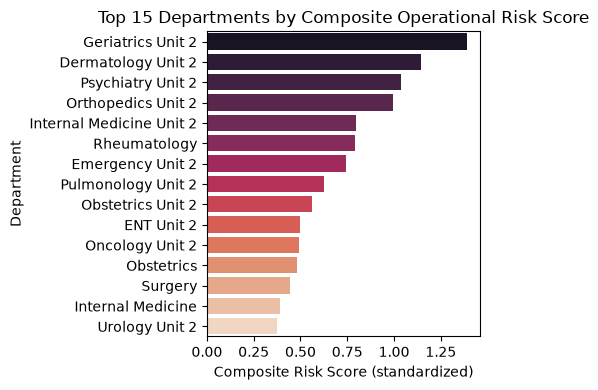

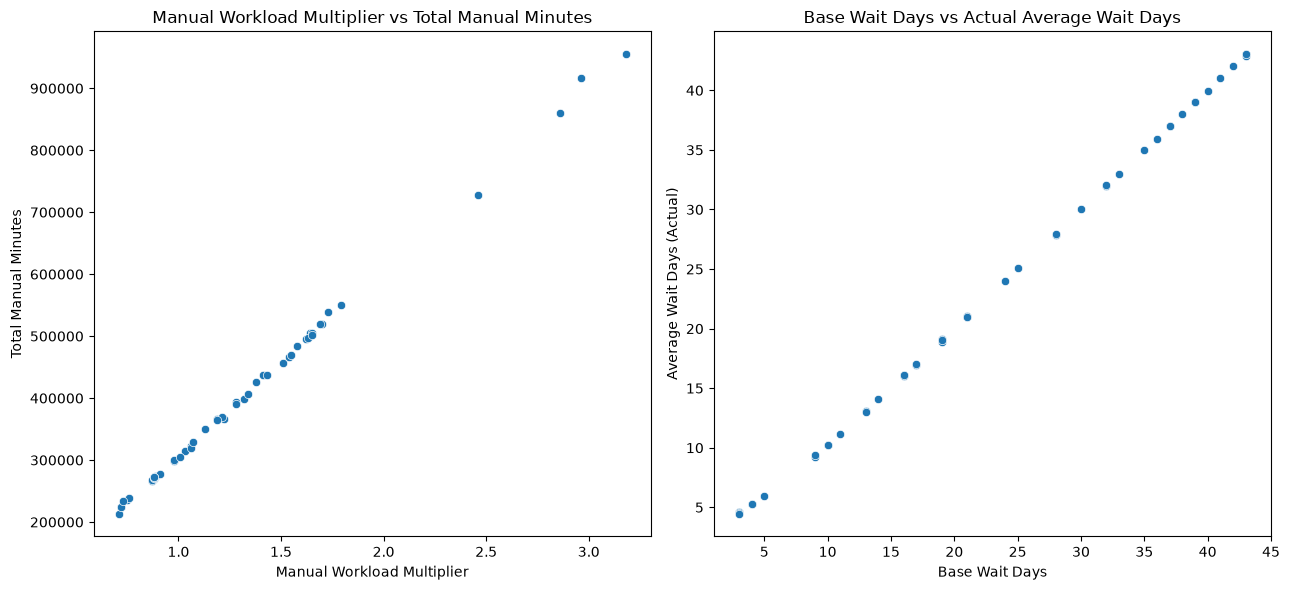

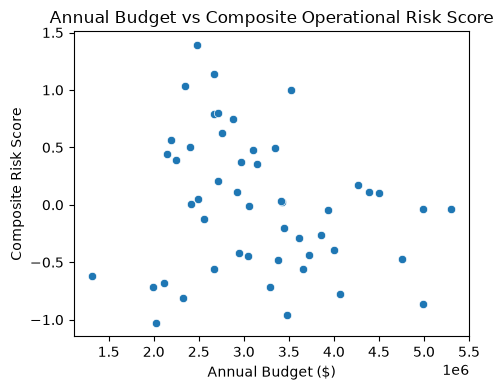

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


mw = pd.read_csv('/Users/vinusiya/Desktop/manual_workflow_clean.csv') 
appt = pd.read_csv('/Users/vinusiya/Desktop/appointments_cleaned.csv') 
dept = pd.read_csv('/Users/vinusiya/Desktop/departments_clean.csv') 
prov = pd.read_csv('/Users/vinusiya/Desktop/cleaned_providers.csv') 
patients = pd.read_csv('/Users/vinusiya/Desktop/patients_cleaned.csv') 



# Part 1

mw_dept = mw.groupby('department_id').agg(
    total_manual_minutes=('manual_minutes', 'sum'),
    avg_manual_minutes=('manual_minutes', 'mean'),
    task_count=('task_id', 'count'),
    error_rate=('error_flag', lambda x: (x == 'Y').mean())
).reset_index()

prov_dept = prov.groupby('department_id').agg(
    avg_overbooking=('overbooking_index', 'mean'),
    strain_rate=('high_admin_strain_flag', 'mean'),
    provider_count=('provider_id', 'count')
).reset_index()

appt_dept = appt.groupby('department_id').agg(
    avg_wait_days=('wait_days', 'mean'),
    noshow_rate=('status', lambda x: (x == 'No Show').mean()),
    appt_count=('appointment_id', 'count')
).reset_index()

master = (dept
          .merge(mw_dept, on='department_id', how='left')
          .merge(prov_dept, on='department_id', how='left')
          .merge(appt_dept, on='department_id', how='left'))

print(f"Master table shape: {master.shape}")
master.to_csv(os.path.expanduser('~/department_master.csv'), index = False)

# Composite operational risk score (z-score standardization)
risk_cols = ['total_manual_minutes', 'avg_overbooking', 'avg_wait_days', 'noshow_rate', 'error_rate']
z = master[risk_cols].apply(lambda c: (c - c.mean()) / c.std())
master['composite_strain_score'] = z.mean(axis=1)

top_worst = master.sort_values('composite_strain_score', ascending=False).head(10)
print("\nTop 10 departments by composite operational risk:")
print(top_worst[['department_id', 'department_name', 'composite_strain_score'] + risk_cols].round(3).to_string())

# Chart: composite score by department (top 15)
plt.figure(figsize=(5, 4))
top15 = master.sort_values('composite_strain_score', ascending=False).head(15)
sns.barplot(data=top15, x='composite_strain_score', y='department_name', palette='rocket')
plt.title('Top 15 Departments by Composite Operational Risk Score')
plt.xlabel('Composite Risk Score (standardized)')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

# Chart: department attribute vs downstream outcome 
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.scatterplot(data=master, x='manual_workload_multiplier', y='total_manual_minutes', ax=axes[0])
axes[0].set_title('Manual Workload Multiplier vs Total Manual Minutes')
axes[0].set_xlabel('Manual Workload Multiplier')
axes[0].set_ylabel('Total Manual Minutes')
sns.scatterplot(data=master, x='base_wait_days', y='avg_wait_days', ax=axes[1])
axes[1].set_title('Base Wait Days vs Actual Average Wait Days')
axes[1].set_xlabel('Base Wait Days')
axes[1].set_ylabel('Average Wait Days (Actual)')
plt.tight_layout()
plt.show()

# Chart: budget vs composite risk (checking if spend reduces risk)
plt.figure(figsize=(5, 4))
sns.scatterplot(data=master, x='annual_budget', y='composite_strain_score')
plt.title('Annual Budget vs Composite Operational Risk Score')
plt.xlabel('Annual Budget ($)')
plt.ylabel('Composite Risk Score')
plt.tight_layout()
plt.show()

# Correlation heatmap of everything
        #### Maybe not this one
# corr_cols = ['annual_budget', 'base_wait_days', 'manual_workload_multiplier', 'claim_denial_risk',
#              'lab_delay_risk', 'total_manual_minutes', 'error_rate', 'avg_overbooking',
#              'strain_rate', 'avg_wait_days', 'noshow_rate']
# plt.figure(figsize=(10, 10))
# sns.heatmap(master[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
# plt.title('Department-Level Metric Correlations')
# plt.tight_layout()
# plt.show()



# Part 2
 ##### Not very useful graphs but still keep in case

# patient_appt = appt.merge(patients[['patient_id', 'chronic_diabetes', 'chronic_hypertension']],
#                           on='patient_id', how='left')

# # Comorbidity segment
# def comorbidity(row):
#     if row['chronic_diabetes'] and row['chronic_hypertension']:
#         return 'Both'
#     elif row['chronic_diabetes']:
#         return 'Diabetes only'
#     elif row['chronic_hypertension']:
#         return 'Hypertension only'
#     return 'Neither'

# patient_appt['comorbidity_segment'] = patient_appt.apply(comorbidity, axis=1)

# # Visit type share by comorbidity segment
# visit_by_comorbidity = pd.crosstab(patient_appt['comorbidity_segment'], patient_appt['visit_type'], normalize='index')
# print("\nVisit type share by comorbidity segment:")
# print(visit_by_comorbidity.round(3))

# # No-show rate by comorbidity segment
# noshow_by_comorbidity = patient_appt.groupby('comorbidity_segment').apply(
#     lambda d: (d['status'] == 'No Show').mean()
# )
# print("\nNo-show rate by comorbidity segment:")
# print(noshow_by_comorbidity.round(3))

# # Average appointments per patient by comorbidity segment (visit volume driver)
# appts_per_patient = patient_appt.groupby(['patient_id', 'comorbidity_segment']).size().reset_index(name='appt_count')
# avg_appts_per_patient = appts_per_patient.groupby('comorbidity_segment')['appt_count'].mean()
# print("\nAverage appointments per patient by comorbidity segment:")
# print(avg_appts_per_patient.round(2))

# # Chart: visit type mix by comorbidity segment
# plt.figure(figsize=(5, 4))
# visit_by_comorbidity.plot(kind='bar', stacked=True, figsize=(5,4))
# plt.title('Visit Type Mix by Chronic Condition Segment')
# plt.ylabel('Proportion of Appointments')
# plt.xlabel('Comorbidity Segment')
# plt.xticks(rotation=0)
# plt.legend(title='Visit Type', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show

# # Chart: appointment volume per patient by comorbidity segment
# plt.figure(figsize=(5,4))
# avg_appts_per_patient.sort_values(ascending=False).plot(kind='bar', color=sns.color_palette('viridis', 4))
# plt.title('Average Appointments per Patient by Chronic Condition Segment')
# plt.ylabel('Avg Appointments per Patient')
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show